C:\Users\Farrukh\AppData\Local\Temp\ipykernel_15512\97736773.py:24: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  avg_oil = oil.resample('Q').mean()


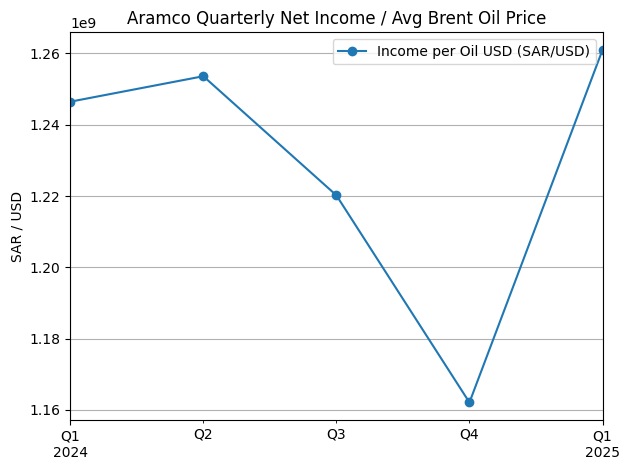

           Net Income (SAR)  Avg Brent (USD) Income per Oil USD (SAR/USD)
2025-03-31    95676000000.0        75.874603            1260975293.403903
2024-12-31    86756000000.0        74.656094            1162075265.959117
2024-09-30    97621000000.0        80.005077            1220185065.178556
2024-06-30   106158000000.0        84.682097             1253606181.75377
2024-03-31   103356000000.0        82.919683              1246459185.9784


In [1]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
from pandas_datareader import data as pdr
import datetime as dt

# 1. Fetch Aramco (2222.SR) Financials using yfinance
ticker = yf.Ticker("2222.SR")
financials = ticker.quarterly_financials.T

# Get only net income
net_income = financials['Net Income']

# Format: Index = Quarter End
net_income.index = pd.to_datetime(net_income.index)

# 2. Fetch Brent oil prices from FRED
start = net_income.index.min() - pd.Timedelta(days=90)
end = net_income.index.max() + pd.Timedelta(days=90)

oil = pdr.DataReader('DCOILBRENTEU', 'fred', start, end)

# Resample to quarterly average
avg_oil = oil.resample('Q').mean()

# 3. Merge Net Income with Avg Oil Price by Quarter
df = pd.DataFrame()
df['Net Income (SAR)'] = net_income
df['Avg Brent (USD)'] = avg_oil['DCOILBRENTEU']

# Drop NaNs
df = df.dropna()

# 4. Calculate Ratio
df['Income per Oil USD (SAR/USD)'] = df['Net Income (SAR)'] / df['Avg Brent (USD)']

# 5. Plotting
df[['Income per Oil USD (SAR/USD)']].plot(marker='o', title='Aramco Quarterly Net Income / Avg Brent Oil Price')
plt.ylabel('SAR / USD')
plt.grid(True)
plt.tight_layout()
plt.show()

# Optional: Export to CSV
df.to_csv('aramco_income_vs_oil.csv')

print(df)
